# Plug-flow reactor (spatial DAE)

A steady-state PFR is a boundary-value problem in the axial coordinate: gas concentrations evolve along the reactor while the surface coverages sit at a local quasi-steady state. discopt.mkm maps this onto orthogonal collocation in `z`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root for discopt.mkm

In [2]:
import numpy as np, discopt.mkm as mk
from discopt.mkm.examples import co_oxidation
m, _ = co_oxidation(T=500.0)
CO, O2, CO2 = m._by_name['CO'], m._by_name['O2'], m._by_name['CO2']

## Solve the reactor and check the axial profiles + atom balance

In [3]:
sol = mk.solve_pfr(m, {CO: 1.0, O2: 0.5, CO2: 0.0}, length=4.0, velocity=1.0,
                   cat_density=0.1, nfe=20, ncp=3)
print('status:', sol.status)
for g in (CO, O2, CO2):
    print(f'  {g.name:3s}: inlet={1.0 if g is CO else (0.5 if g is O2 else 0.0):.3f}  outlet={sol.outlet(g):.4f}')
print(f'  CO conversion = {sol.conversion(CO):.3f}')
dCO, dCO2, dO2 = 1.0 - sol.outlet(CO), sol.outlet(CO2), 0.5 - sol.outlet(O2)
print(f'  atom balance: dCO={dCO:.4f} == dCO2={dCO2:.4f},  dO2={dO2:.4f} == 0.5*dCO2={0.5*dCO2:.4f}')

status: optimal
  CO : inlet=1.000  outlet=0.5444
  O2 : inlet=0.500  outlet=0.2722
  CO2: inlet=0.000  outlet=0.4556
  CO conversion = 0.456
  atom balance: dCO=0.4556 == dCO2=0.4556,  dO2=0.2278 == 0.5*dCO2=0.2278


## Profiles along the reactor

`positions()`, `concentration()`, and `coverage()` return aligned 1D arrays. CO and O$_2$ are consumed and CO$_2$ builds up down the bed, while the coverages shift as the gas composition changes.

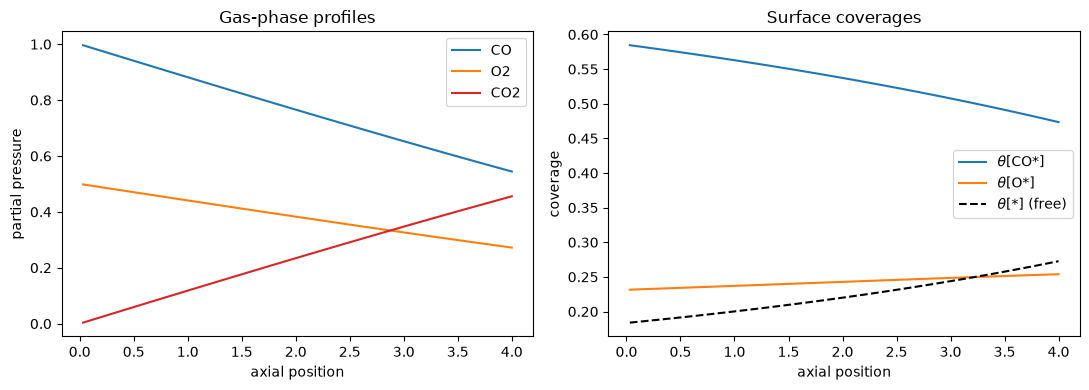

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
z = sol.positions()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for g, c in [(CO, 'C0'), (O2, 'C1'), (CO2, 'C3')]:
    ax[0].plot(z, sol.concentration(g), c, label=g.name)
ax[0].set_xlabel('axial position'); ax[0].set_ylabel('partial pressure')
ax[0].legend(); ax[0].set_title('Gas-phase profiles')
cov_sum = 0
for a in m.adsorbates:
    y = sol.coverage(a); cov_sum = cov_sum + y
    ax[1].plot(z, y, label=f'$\\theta$[{a.name}]')
ax[1].plot(z, 1.0 - cov_sum, 'k--', label=r'$\theta$[*] (free)')
ax[1].set_xlabel('axial position'); ax[1].set_ylabel('coverage')
ax[1].legend(); ax[1].set_title('Surface coverages')
fig.tight_layout()
